In [1]:
# Read and split the file content
with open('Datasets Pretraining/TinyStories-valid.txt', 'r') as file:
    content = file.read()

all_texts = content.split("<|endoftext|>")

In [2]:
import numpy as np
from tqdm.auto import tqdm
import re

def clean_text(text: str) -> str:
    """
    Remove HTML, normalize whitespace, preserve punctuation/numbers/casing.
    """
    text = text.replace('\r', ' ').replace('\n', ' ')
    text = re.sub(r'\s+', ' ', text)
    return text.strip().lower()

# Combine summary + dialogue and split on whitespace
raw_lens = [len(clean_text(s).split()) for s in tqdm(all_texts, total=len(all_texts))]

lens = np.array(raw_lens)

# Print summary stats
def pct(x): return np.percentile(lens, x)

print(f"Total examples    : {len(lens):,}")
print(f"Min / Max words   : {lens.min()} / {lens.max()}")
print(f"Mean ± std        : {lens.mean():.1f} ± {lens.std():.1f}")
print("--- Percentiles (word count per raw text pair) ---")
for p in [50, 60, 70, 80, 90, 95, 99]:
    print(f"{p:>3}% : {pct(p):.0f} words")

del(lens)
del(raw_lens)

/Users/saptarshimallikthakur/Pictures/VLM/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 21990/21990 [00:00<00:00, 33981.40it/s]

Total examples    : 21,990
Min / Max words   : 13 / 841
Mean ± std        : 170.7 ± 75.3
--- Percentiles (word count per raw text pair) ---
 50% : 151 words
 60% : 161 words
 70% : 172 words
 80% : 192 words
 90% : 252 words
 95% : 332 words
 99% : 476 words


In [3]:
import numpy as np
from tqdm.auto import tqdm
import re

def clean_text(text: str) -> str:
    """
    Remove HTML, normalize whitespace, preserve punctuation/numbers/casing.
    """
    text = text.replace('\r', ' ').replace('\n', ' ')
    text = re.sub(r'\s+', ' ', text)
    return text

MAX_LEN = 350

stories = []

for i in all_texts:
    try:
        if len(clean_text(i).strip().split()) < MAX_LEN: 
            stories.append(clean_text(i))
    except:
        pass

del(all_texts)

2000



4000



8000



12000



16000





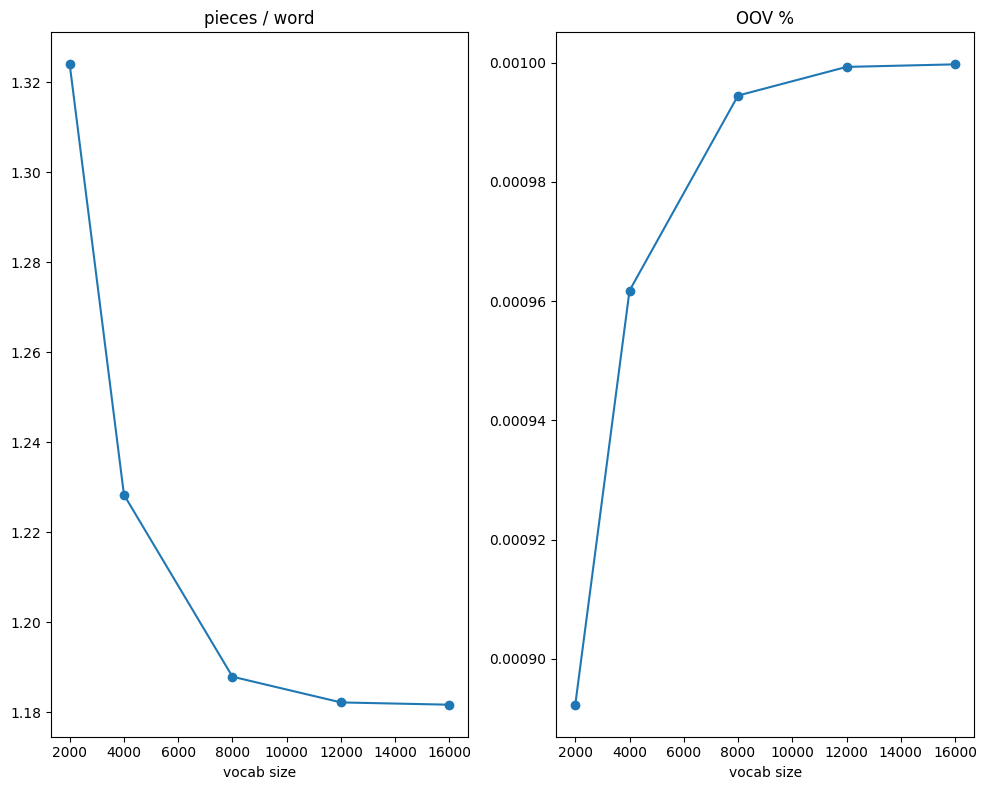

In [4]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers
import matplotlib.pyplot as plt
        
split = int(0.95*len(stories))
train_texts, valid_texts = stories[:split],stories[split:]

def train_tokenizer(text_iter, vocab_size: int) -> Tokenizer:
    tok = Tokenizer(models.BPE(unk_token="[UNK]"))
    tok.pre_tokenizer = pre_tokenizers.Whitespace()
    trainer = trainers.BpeTrainer(vocab_size=vocab_size,
                                  min_frequency=2,
                                  special_tokens=["[UNK]"])
    tok.train_from_iterator(text_iter, trainer)
    return tok

def avg_pieces_per_word(tok: Tokenizer, texts) -> float:
    pieces = words = 0
    for t in texts:
        ids   = tok.encode(t).ids
        pieces += len(ids)
        words  += len(t.split())
    return pieces / words

vocab_sizes = [2000, 4000, 8000, 12000, 16000]
pieces_per_word, oov_rate = [], []

for k in vocab_sizes:
    print(k)
    tok = train_tokenizer(train_texts, k)

    # 1) average sub-words per word on validation set
    pieces_per_word.append(avg_pieces_per_word(tok, valid_texts))

    # 2) OOV percentage on validation set
    unk_id = tok.token_to_id("[UNK]")
    total = unk = 0
    for t in valid_texts:
        ids   = tok.encode(t).ids
        total += len(ids)
        unk   += sum(id_ == unk_id for id_ in ids)
    oov_rate.append(100 * unk / total)

# ── plot ───────────────────────────────────────────────────────────────
plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
plt.plot(vocab_sizes, pieces_per_word, marker='o')
plt.title("pieces / word"); plt.xlabel("vocab size")

plt.subplot(1,2,2)
plt.plot(vocab_sizes, oov_rate, marker='o')
plt.title("OOV %"); plt.xlabel("vocab size")

plt.tight_layout(); plt.show()

In [5]:
VOCAB_SIZE = 4000
SPECIAL_TOKENS = ['[PAD]', '[UNK]', '[BOS]', '[EOS]', '[SEP]','[IMG_TOKEN]']

In [6]:
import re
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import BpeTrainer
from tokenizers.processors import TemplateProcessing

# Initialize and train
tokenizer = Tokenizer(BPE(unk_token='[UNK]'))
tokenizer.pre_tokenizer = Whitespace()
trainer = BpeTrainer(vocab_size=VOCAB_SIZE, special_tokens=SPECIAL_TOKENS)
tokenizer.train_from_iterator(stories, trainer=trainer)

# ── Configure post-processing ────────────────────────────────
pad_id = tokenizer.token_to_id("[PAD]")
unk_id = tokenizer.token_to_id("[UNK]")
bos_id = tokenizer.token_to_id("[BOS]")
eos_id = tokenizer.token_to_id("[EOS]")
sep_id = tokenizer.token_to_id("[SEP]")

tokenizer.post_processor = TemplateProcessing(
    single='$A',
    special_tokens=[],
)

Total samples    : 10,000
Min / Max tokens : 61 / 491
Mean ± std       : 195.5 ± 62.4
--- percentiles (tokens) ---
 50% : 181
 90% : 271
 95% : 335
 99% : 418


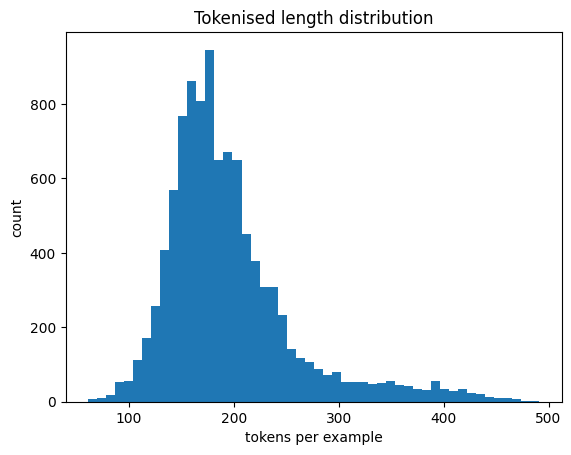

In [7]:
import matplotlib.pyplot as plt
import random

# ------------------------------------------------------------
# 0)  Make sure `tok` points to the FINAL tokenizer
#     → trained on the full corpus with your chosen vocab_size
# ------------------------------------------------------------
tok = tokenizer          # whatever variable you use

# ------------------------------------------------------------
# 1)  Get token counts for every example
#     (here: concatenate summary + dialogue; split if you want)
# ------------------------------------------------------------
lens = []
rnd_story = random.choices(stories, k=10000) 
for txt in rnd_story:
    ids   = tok.encode(txt).ids
    lens.append(len(ids))

lens = np.array(lens)

# ------------------------------------------------------------
# 2)  Print key stats
# ------------------------------------------------------------
def pct(x): return np.percentile(lens, x)

print(f"Total samples    : {len(lens):,}")
print(f"Min / Max tokens : {lens.min()} / {lens.max()}")
print(f"Mean ± std       : {lens.mean():.1f} ± {lens.std():.1f}")
print("--- percentiles (tokens) ---")
for p in (50, 90, 95, 99):
    print(f"{p:>3}% : {pct(p):.0f}")

# ------------------------------------------------------------
# 3)  Quick histogram    (no seaborn, single plot, no colors set)
# ------------------------------------------------------------
plt.hist(lens, bins=50)
plt.xlabel("tokens per example")
plt.ylabel("count")
plt.title("Tokenised length distribution")
plt.show()

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from functools import partial

BATCH_SIZE = 32
MAX_TOKEN_LEN = 512
del(lens)

class TextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len, bos_id, sep_id, eos_id, pad_id):
        self.texts = texts  # List of (context, question, answer) tuples
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.bos_id = bos_id
        self.sep_id = sep_id
        self.eos_id = eos_id
        self.pad_id = pad_id

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        content = self.texts[idx]

        # Encode on-the-fly
        para = self.tokenizer.encode(content)

        # Combine tokens
        ids = [self.bos_id] + para.ids 

        # Truncate
        ids = ids[:self.max_len]

        # Prepare labels
        labels = ids[1:] + [self.eos_id]

        # Pad to max_len
        ids += [self.pad_id] * (self.max_len - len(ids))
        labels += [self.pad_id] * (self.max_len - len(labels))

        # Convert to tensors
        ids_t = torch.tensor(ids, dtype=torch.long)
        labels_t = torch.tensor(labels, dtype=torch.long)

        return {"input_ids": ids_t,"labels": labels_t}

dataset = TextDataset(
    texts=stories,
    tokenizer=tokenizer,
    max_len=MAX_TOKEN_LEN,
    bos_id=bos_id,
    sep_id=sep_id,
    eos_id=eos_id,
    pad_id=pad_id
)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
del(stories)
del(dataset)

In [9]:
vocab = tokenizer.get_vocab()           # indices 0 … V

id_to_token = {idx: tok for tok, idx in vocab.items()}

# 2) Decoder: drop PADs, replace unknown IDs with '?'
def decode_token_ids(token_ids: list[int]) -> str:
    tokens = []
    for tid in token_ids:
        if tid == pad_id:
            continue
        tokens.append(id_to_token.get(tid, '?'))
    return ' '.join(tokens)

# Take one batch
batch = next(iter(loader))

input_ids = batch['input_ids']   # shape: [B, MAX_LEN]
labels    = batch['labels']      # shape: [B, MAX_LEN]

for i in range(input_ids.size(0)):
    ids_row = input_ids[i].tolist()
    lbl_row = labels[i].tolist()

    print(f"\n🟢 Sample {i+1}")
    print("  Input IDs: ", ids_row)
    print("  Decoded:   ", decode_token_ids(ids_row))  # Assumes you have this function defined
    print("  Label. :   ", decode_token_ids(lbl_row))  # Assumes you have this function defined
    print("  Label IDs: ", lbl_row)


🟢 Sample 1
  Input IDs:  [2, 215, 236, 60, 192, 198, 112, 60, 300, 18, 135, 438, 103, 340, 575, 161, 2792, 1455, 78, 18, 135, 310, 219, 2408, 105, 101, 919, 104, 2129, 104, 3432, 318, 60, 1419, 18, 135, 350, 101, 966, 85, 2787, 1455, 78, 6, 216, 158, 99, 222, 60, 1050, 229, 18, 211, 112, 60, 545, 163, 2792, 1455, 78, 189, 486, 108, 18, 135, 1775, 343, 112, 503, 101, 545, 18, 135, 177, 463, 964, 1245, 60, 2792, 229, 696, 18, 410, 99, 387, 103, 563, 108, 18, 135, 1455, 102, 101, 545, 104, 722, 108, 169, 18, 425, 99, 722, 108, 16, 99, 112, 166, 1062, 6, 1465, 101, 545, 112, 575, 161, 1383, 18, 135, 299, 104, 1455, 102, 163, 608, 18, 135, 1073, 169, 101, 1383, 104, 153, 16, 7, 946, 144, 170, 2792, 1455, 78, 246, 833, 606, 18, 135, 112, 149, 208, 99, 177, 1455, 102, 101, 545, 104, 722, 108, 169, 18, 211, 112, 60, 166, 447, 229, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [10]:
from model_sparse import *

device='mps'

class BuildTransformer(torch.nn.Module):
    def __init__(self, *, num_layers, d_model, num_heads, input_vocab_size, dropout_rate=0.1):
        super().__init__()
        self.token_embedding = TokenEmbedding(vocab_size=input_vocab_size, d_model=d_model)
        self.decoder = Decoder(num_layers=num_layers, d_model=d_model, num_heads=num_heads,
                               input_vocab_size=input_vocab_size, dropout_rate=dropout_rate)

    def forward(self, inputs):
        x = inputs
        # Create padding mask (True for padding tokens, False otherwise)
        pad_mask = (x == 0)  # Assuming padding token is 0, as in TokenEmbedding's padding_idx
        x = self.token_embedding(x)
        x = self.decoder(x, pad_mask=pad_mask)
        return x

# Example instantiation
num_layers = 4
d_model = 256
num_heads = 8  # 32 dim per head
dropout_rate = 0.1

model = BuildTransformer(
    num_layers=num_layers,
    d_model=d_model,
    num_heads=num_heads,
    input_vocab_size=VOCAB_SIZE,
    dropout_rate=dropout_rate
)

model.to(device)

# Build weights by running a forward pass
dummy = torch.zeros((1, MAX_TOKEN_LEN), dtype=torch.int32).to(device)
_ = model(dummy)

In [11]:
print("Trainable Parameters:")
print("-" * 60)
total_params = 0
for name, param in model.named_parameters():
    if param.requires_grad:
        param_count = param.numel()
        print(f"Parameter: {name:<50} Shape: {str(param.shape):<20} Parameters: {param_count}")
        total_params += param_count
print("-" * 60)
print(f"Total Trainable Parameters: {total_params:,}")

Trainable Parameters:
------------------------------------------------------------
Parameter: token_embedding.embedding.weight                   Shape: torch.Size([4000, 256]) Parameters: 1024000
Parameter: decoder.dec_layers.0.causal_self_attention.mha.wq.weight Shape: torch.Size([256, 256]) Parameters: 65536
Parameter: decoder.dec_layers.0.causal_self_attention.mha.wk.weight Shape: torch.Size([256, 256]) Parameters: 65536
Parameter: decoder.dec_layers.0.causal_self_attention.mha.wv.weight Shape: torch.Size([256, 256]) Parameters: 65536
Parameter: decoder.dec_layers.0.causal_self_attention.mha.wo.weight Shape: torch.Size([256, 256]) Parameters: 65536
Parameter: decoder.dec_layers.0.causal_self_attention.rmsnorm.scale Shape: torch.Size([256])    Parameters: 256
Parameter: decoder.dec_layers.0.ffn.swiglu.lin1.weight        Shape: torch.Size([1024, 256]) Parameters: 262144
Parameter: decoder.dec_layers.0.ffn.swiglu.lin2.weight        Shape: torch.Size([256, 512]) Parameters: 131072
Param

In [12]:
print("Non Trainable Parameters:")
print("-" * 60)
total_params = 0
for name, param in model.named_parameters():
    if not param.requires_grad:
        param_count = param.numel()
        print(f"Parameter: {name:<50} Shape: {str(param.shape):<20} Parameters: {param_count}")
        total_params += param_count
print("-" * 60)
print(f"Total Non Trainable Parameters: {total_params:,}")

Non Trainable Parameters:
------------------------------------------------------------
------------------------------------------------------------
Total Non Trainable Parameters: 0


In [13]:
def pad_to_stride(ids: torch.Tensor, pad_id: int, stride: int) -> torch.Tensor:
    """
    ids : (B, T)  int32/64
    Returns ids padded on the right so that len % stride == 0.
    """
    B, T = ids.shape
    rem  = (-T) % stride
    if rem == 0:
        return ids
    pad = ids.new_full((B, rem), pad_id)
    return torch.cat([ids, pad], dim=1)

def encode_input(text: str) -> torch.Tensor:
    """
    Returns [BOS] dialogue [EOS] *without* any padding.
    """
    ids = [bos_id] + tokenizer.encode(clean_text(text)).ids      
    return torch.tensor(ids, dtype=torch.int32)     # 1-D tensor

@torch.no_grad()
def generate_summary(
    text_ids: torch.Tensor,
    model: torch.nn.Module,
    max_new: int = 120,
    temperature: float = 1,
    device: str = "cpu"
) -> torch.Tensor:
    """
    Generate tokens auto-regressively: [BOS] text [EOS]
    """
    model.eval()
    prompt = text_ids.unsqueeze(0).to(device)  # (1, T)
    
    for _ in range(max_new):
        L0     = prompt.shape[1]    
        prompt_padded = pad_to_stride(prompt, pad_id=pad_id, stride=32)

        if L0 > MAX_LEN:
            break

        logits = model(prompt_padded)[:,L0-1,:] / temperature
        next_id = torch.distributions.Categorical(logits=logits).sample().unsqueeze(0)
        prompt = torch.cat([prompt, next_id], dim=1)

        if next_id[0, 0] == eos_id:
            break

    return prompt.squeeze(0)

def display_text(text: str, model, temp=1, device="cpu"):
    # 1. Encode input
    text_ids = encode_input(text)

    # 2. Generate full sequence
    full_ids = generate_summary(text_ids, model, temperature=temp, device=device)

    # 3. Convert to list
    full_ids_list = full_ids.tolist()

    # 4. Decode
    text_str = decode_token_ids(full_ids_list)

    # 5. Print
    print("Text:", text_str)

In [14]:
from torch.optim.lr_scheduler import _LRScheduler
import math
from tqdm import tqdm

class CustomLRScheduler(_LRScheduler):
    def __init__(self, optimizer, total_steps, warmup_steps_ratio, min_lr, max_lr, last_epoch=-1):
        self.total_steps = total_steps
        self.warmup_steps = int(total_steps * warmup_steps_ratio)
        self.min_lr = min_lr
        self.max_lr = max_lr
        super(CustomLRScheduler, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        current_step = self.last_epoch
        if current_step < self.warmup_steps:
            lr = self.min_lr + (self.max_lr - self.min_lr) * (current_step / self.warmup_steps)
        else:
            progress = (current_step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
            decay_factor = math.exp(-3.0 * progress)
            lr = self.min_lr + (self.max_lr - self.min_lr) * decay_factor
            lr = max(lr, self.min_lr)
        return [lr for _ in self.base_lrs]
    
EPOCHS = 20
LEARNING_RATE_MIN = 1e-6
LEARNING_RATE_MAX = 1e-3
WARMUP_RATIO = 0.1

# --- Optimizer ---
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE_MAX, betas=(0.9, 0.98), eps=1e-9) # Initial LR can be max, scheduler will adjust
criterion = torch.nn.CrossEntropyLoss(ignore_index=pad_id)

# --- Calculate total steps and initialize scheduler ---
total_steps = len(loader) * EPOCHS
scheduler = CustomLRScheduler(
    optimizer,
    total_steps=total_steps,
    warmup_steps_ratio=WARMUP_RATIO,
    min_lr=LEARNING_RATE_MIN,
    max_lr=LEARNING_RATE_MAX
)

for epoch in range(1, EPOCHS + 1):
    model.train()
    tot_loss = tot_correct = tot_tokens = 0.0

    pbar = tqdm(loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=True)
    for batch in pbar:
        ids  = batch["input_ids"].to(device)          # (B, T)
        tgt  = batch["labels"].to(device)             # (B, T)

        optimizer.zero_grad()
        logits = model(ids)                           # (B, T, V)

        # ---- loss ----
        loss = criterion(logits.view(-1, logits.size(-1)), tgt.view(-1))  # (B * T, V) & (B*T,)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        # ---- metrics (no grad) ----
        with torch.no_grad():
            preds   = logits.argmax(-1)
            valid   = (tgt != pad_id)                 # bool mask
            correct = (preds == tgt) & valid
            n_tok   = valid.sum().item()

            tot_correct += correct.sum().item()
            tot_tokens  += n_tok
            tot_loss    += loss.item() * n_tok        # de‑average

        pbar.set_postfix(
            loss=f"{tot_loss / tot_tokens:.4f}",
            acc=f"{tot_correct / tot_tokens:.4f}",
            lr=f"{scheduler.get_last_lr()[0]:.6f}"
        )

    display_text('john saw coffee in kitchen',model,device='mps')

Epoch 1/20: 100%|██████████| 658/658 [08:37<00:00,  1.27it/s, acc=0.2234, loss=4.9479, lr=0.000501]


Text: [BOS] jo h n saw coffee in kitchen and he saw a big tree with his name . One day , he wanted to help . He found a tall ine m sorry but couldn ' t want to count what was , eventually he reached the cake , so he heard himself . " Yes , you would be very anything their shoes ?" The man was already disappeared to take a picture about an adventure . Peter could put the story that top of you like it was no feed the bear in a big hug . He climbed to the cave and put it on the market . Mom and Ben flew away , until it was bow towards them . They explained that the


Epoch 2/20: 100%|██████████| 658/658 [08:29<00:00,  1.29it/s, acc=0.3716, loss=3.1679, lr=0.001000]


Text: [BOS] jo h n saw coffee in kitchen . There were there nice t woods , a thief named Amy man . Amy wanted to do something new . Sam and tried to explore , but they did not find them . Sam said , " Do you want to mail my stuff with me for ?" Mia and Sue decided to go to the park . They played in the air and had fun in there . Then they car ed off to show them to her his mom and dad . Sue felt happy knowing he had her own new adventures together . Soon Sue and D es walked until they found some pass and water . They had a fun yummy cake shop and spread


Epoch 3/20: 100%|██████████| 658/658 [08:30<00:00,  1.29it/s, acc=0.4158, loss=2.7778, lr=0.000847]


...

Text: [BOS] jo h n saw coffee in kitchen , old magaz ine ' s coffee that made her Josh feel warm . It was terri fi ed , with enthus i b ts stri b are delight ful and went to the kitchen to try the blue toast . Soon , Jim was looking for something special . He grabbed one half , then he un load ed it with all his ch restaurant . He carefully picked some berry and brought it to a ster piece of milk . Jim was so excited ! He carefully put the batter in his bedroom and grabbed the cookie carefully . This he was pr ed and peaceful ly , that John looked much better at the carto on .


Epoch 16/20: 100%|██████████| 658/658 [08:22<00:00,  1.31it/s, acc=0.5155, loss=2.0269, lr=0.000098]


Text: [BOS] jo h n saw coffee in kitchen . He was so excited he had never done his job and he couldn ' t wait to use it . He had put all his pin floor and his sto mach started to make his own b rain coat . So his mom came to the house and asked , " What is wrong , Jack ?" " I don ' t need it , I ' d forgotten you !" he replied with a big smile . His Mom laughed as they both looked at the hose . " That ' s not fair and it ' s just a little dirty shirt ," she said happily . Suddenly , the icy water start again in the garden


Epoch 17/20:  90%|█████████ | 595/658 [07:35<00:48,  1.31it/s, acc=0.5173, loss=2.0161, lr=0.000084]


KeyboardInterrupt: 

In [ ]:
display_text('once in a mountain',model,device='mps',temp=1)

In [ ]:
display_text('Sandy was a boy who lived',model,device='mps',temp=0.5)

In [ ]:
display_text('Sandy went to a forest',model,device='mps',temp=0.5)

In [ ]:
kkkk

In [ ]:
tokenizer.save("Pre-Trained Directory/tokenizer.json")

torch.save(model.state_dict(), 'Pre-Trained Directory/pretrained_weights.pth')

torch.save(
    {"token_embedding": model.token_embedding.state_dict()},
    "Pre-Trained Directory/pretrained_embedding_dict.pth"
)

torch.save(
    {"decoder": model.decoder.state_dict()},
    "Pre-Trained Directory/pretrained_decoder_dict.pth"
)

In [ ]:
model2 = BuildTransformer(
    num_layers=num_layers,
    d_model=d_model,
    num_heads=num_heads,
    input_vocab_size=VOCAB_SIZE,
    dropout_rate=dropout_rate
)

# Build weights by running a forward pass
dummy = torch.zeros((1, MAX_TOKEN_LEN), dtype=torch.int32)
_ = model2(dummy)

model2.load_state_dict(torch.load('Pre-Trained Directory/pretrained_weights.pth'))

In [ ]:
display_text('once in a mountain',model2,device='cpu', temp=1)